202235275 심찬기

In [120]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt



path = '/content/drive/MyDrive/Colab Notebooks/titanic.csv'
df =pd.read_csv(path)

df


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [121]:
le = LabelEncoder()
df['Sex'] =le.fit_transform(df['Sex']) #label encoding
df['Embarked'] =le.fit_transform(df['Embarked'])
df['Name'] =le.fit_transform(df['Name'])
df['Ticket'] =le.fit_transform(df['Ticket'])
df['Cabin'] =le.fit_transform(df['Cabin'])
df = df.drop('PassengerId', axis = 1)
df = df.drop('Cabin', axis = 1)




#df.isnull().sum() #age는 제거x cabin은 필요없는 feature --> 평균값으로 채우기

df['Age']=df['Age'].fillna(df['Age'].mean())

print(df.isnull().sum() )

print(df)

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64
     Survived  Pclass  Name  Sex        Age  SibSp  Parch  Ticket     Fare  \
0           0       3   108    1  22.000000      1      0     523   7.2500   
1           1       1   190    0  38.000000      1      0     596  71.2833   
2           1       3   353    0  26.000000      0      0     669   7.9250   
3           1       1   272    0  35.000000      1      0      49  53.1000   
4           0       3    15    1  35.000000      0      0     472   8.0500   
..        ...     ...   ...  ...        ...    ...    ...     ...      ...   
886         0       2   548    1  27.000000      0      0     101  13.0000   
887         1       1   303    0  19.000000      0      0      14  30.0000   
888         0       3   413    0  29.699118      1      2     675  23.4500   
889         1       1    81    1  26.000000      0      0       8  

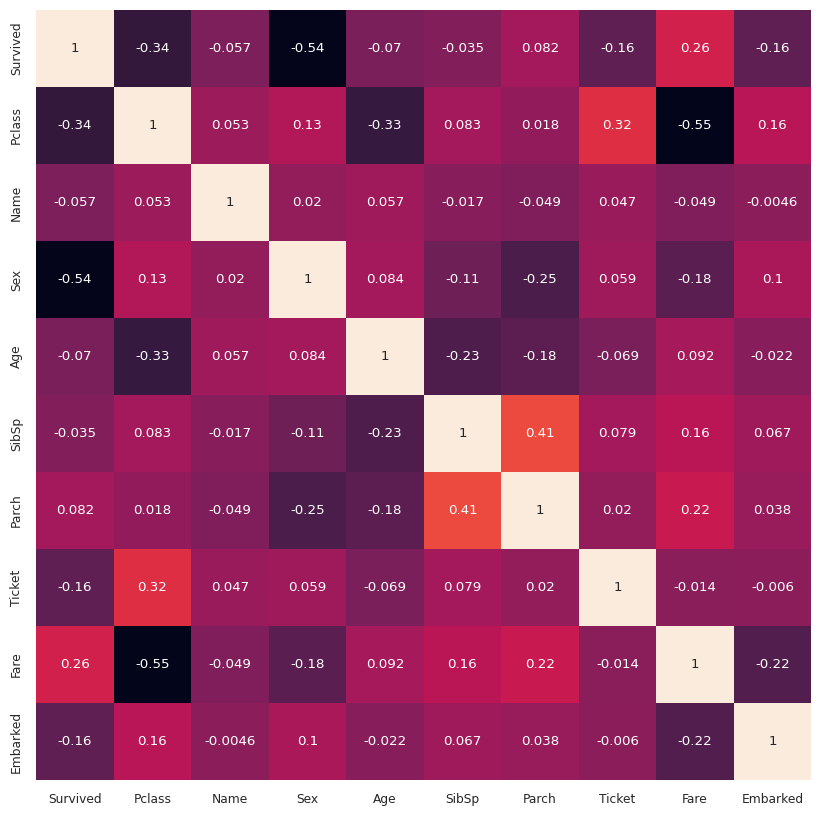

In [122]:
df_corr=df.corr()

#히트맵
plt.figure(figsize=(10,10))
sns.set(font_scale=0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
plt.show()

## 모든 feature(cabin제외)

In [123]:
y=df['Survived']
y


,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [124]:
X=df.drop('Survived', axis=1) #feature selection
X

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,3,108,1,22.000000,1,0,523,7.2500,2
1,1,190,0,38.000000,1,0,596,71.2833,0
2,3,353,0,26.000000,0,0,669,7.9250,2
3,1,272,0,35.000000,1,0,49,53.1000,2
4,3,15,1,35.000000,0,0,472,8.0500,2
...,...,...,...,...,...,...,...,...,...
886,2,548,1,27.000000,0,0,101,13.0000,2
887,1,303,0,19.000000,0,0,14,30.0000,2
888,3,413,0,29.699118,1,2,675,23.4500,2
889,1,81,1,26.000000,0,0,8,30.0000,0


In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)

In [126]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))


--- Logistic Regression Classifier ---
0.7802690582959642
[[115  24]
 [ 25  59]]


In [127]:
clf_dt = DecisionTreeClassifier(random_state=0)
clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))



--- Decision Tree Classifier ---
0.7309417040358744
[[103  36]
 [ 24  60]]


In [128]:
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

print ("\n--- Radom Forest ---")
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
print(accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))


--- Radom Forest ---
0.852017937219731
[[127  12]
 [ 21  63]]


## co-relation

In [129]:
y1=df['Survived']

In [130]:
X1 = df[['Fare','Pclass','Sex']]
X1

,Fare,Pclass,Sex
0,7.2500,3,1
1,71.2833,1,0
2,7.9250,3,0
3,53.1000,1,0
4,8.0500,3,1
...,...,...,...
886,13.0000,2,1
887,30.0000,1,0
888,23.4500,3,0
889,30.0000,1,1


In [131]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.25,random_state=0)

In [132]:
clf_lr1 = LogisticRegression(random_state=0)
clf_lr1.fit(X1_train, y1_train)

pred_lr = clf_lr1.predict(X1_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y1_test, pred_lr))
print (confusion_matrix(y1_test, pred_lr))


--- Logistic Regression Classifier ---
0.7802690582959642
[[115  24]
 [ 25  59]]


In [133]:
clf_dt1 = DecisionTreeClassifier(random_state=0)
clf_dt1.fit(X1_train, y1_train)

pred_dt = clf_dt1.predict(X1_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y1_test, pred_dt))
print (confusion_matrix(y1_test, pred_dt))


--- Decision Tree Classifier ---
0.7937219730941704
[[115  24]
 [ 22  62]]


In [134]:
print ("\n--- Radom Forest ---")
rf_clf1 = RandomForestClassifier(random_state=0)
rf_clf1.fit(X1_train, y1_train)
pred = rf_clf1.predict(X1_test)
print(accuracy_score(y1_test,pred))
print (confusion_matrix(y1_test, pred))


--- Radom Forest ---
0.8071748878923767
[[116  23]
 [ 20  64]]
